# 🚁 DIP Project — Gün 7: ByteTrack + YOLOv8 Entegrasyonu
YOLOv8 detection çıktısını ByteTrack tracking algoritmasına bağlıyoruz.

> **Gereksinim:** Gün 5 tamamlanmış, `best.pt` Drive'da mevcut olmalı.

## 0️⃣ ByteTrack + supervision kurulumu

In [1]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + list(args))

pip('numpy>=1.23,<2', '--force-reinstall')
pip('supervision>=0.21.0', 'ultralytics==8.2.0')

print('=' * 55)
print('✅ Kurulum tamam!')
print()
print('  >>> Runtime > Restart Runtime yap <<<')
print('  Restart sonrası bu hücreyi ATLA, sonrakinden başla!')
print('=' * 55)

✅ Kurulum tamam!

  >>> Runtime > Restart Runtime yap <<<
  Restart sonrası bu hücreyi ATLA, sonrakinden başla!


## 1️⃣ Drive + Model Yükle

In [1]:
MODEL_PATH   = '/content/drive/MyDrive/DIP_Project/runs/yolov8s_visdrone_v1/weights/best.pt'
PROJECT_DIR  = '/content/drive/MyDrive/DIP_Project'
DATASET_ROOT = f'{PROJECT_DIR}/datasets/VisDrone'


In [3]:
import torch, os, cv2
import numpy as np
import supervision as sv
from ultralytics import YOLO

print(f'✅ supervision: {sv.__version__}')
print(f'✅ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR  = '/content/drive/MyDrive/DIP_Project'
DATASET_ROOT = f'{PROJECT_DIR}/datasets/VisDrone'
MODEL_PATH   = f'{PROJECT_DIR}/runs/yolov8s_visdrone_v1/weights/best.pt'
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'

model = YOLO(MODEL_PATH)
print(f'✅ Model: {MODEL_PATH}')
print(f'✅ Device: {DEVICE}')


✅ supervision: 0.28.0
✅ GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model: /content/drive/MyDrive/DIP_Project/runs/yolov8s_visdrone_v1/weights/best.pt
✅ Device: cuda


In [3]:
import glob

pts = glob.glob('/content/drive/**/*best.pt', recursive=True)
for p in pts:
    print(p)


/content/drive/MyDrive/DIP_Project/runs/yolov8s_visdrone_v1/weights/best.pt


In [3]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + list(args))

pip('--force-reinstall', 'opencv-python-headless==4.10.0.84')
pip('--force-reinstall', 'supervision>=0.21.0')
pip('ultralytics>=8.3.0')

print('✅ Yeniden yüklendi — Runtime > Restart Runtime yap, sonra devam et')


✅ Yeniden yüklendi — Runtime > Restart Runtime yap, sonra devam et


## 2️⃣ ByteTracker Başlat

In [4]:
# Varsayılan ByteTrack config — Gün 8'de hiperparametre optimizasyonu yapılacak
byte_tracker = sv.ByteTrack(
    track_activation_threshold = 0.25,   # düşük threshold: drone'dan küçük nesneler için
    lost_track_buffer          = 30,     # 30 frame kayıp sonrası track sil
    minimum_matching_threshold = 0.8,    # IoU eşiği
    frame_rate                 = 30,
    minimum_consecutive_frames = 1,
)
print('✅ ByteTracker hazır!')
print(f'   track_activation_threshold : 0.25')
print(f'   lost_track_buffer          : 30 frame')
print(f'   minimum_matching_threshold : 0.8')

✅ ByteTracker hazır!
   track_activation_threshold : 0.25
   lost_track_buffer          : 30 frame
   minimum_matching_threshold : 0.8


## 3️⃣ YOLOv8 → ByteTrack Pipeline Fonksiyonu

In [5]:
def yolo_to_sv_detections(result) -> sv.Detections:
    """YOLOv8 sonuç nesnesini supervision Detections formatına çevirir."""
    boxes  = result.boxes.xyxy.cpu().numpy()   # [N,4]
    confs  = result.boxes.conf.cpu().numpy()   # [N]
    cls_ids= result.boxes.cls.cpu().numpy().astype(int)  # [N]
    return sv.Detections(
        xyxy       = boxes,
        confidence = confs,
        class_id   = cls_ids,
    )


CLASS_NAMES = [
    'pedestrian','people','bicycle','car','van',
    'truck','tricycle','awning-tricycle','bus','motor'
]

# Annotator'lar — görselleştirme için
box_annotator   = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.4, text_thickness=1)
trace_annotator = sv.TraceAnnotator(thickness=2, trace_length=30)

print('✅ Pipeline fonksiyonları tanımlandı!')

✅ Pipeline fonksiyonları tanımlandı!


## 4️⃣ Test Video'su Seç (VisDrone sekansı)

In [6]:
from pathlib import Path

# VisDrone video sekanslarını ara
video_dirs = [
    f'{DATASET_ROOT}/VisDrone2019-VID-val/sequences',
    f'{DATASET_ROOT}/sequences',
]

VIDEO_DIR  = None
FRAME_LIST = []

for vd in video_dirs:
    p = Path(vd)
    if p.exists():
        seqs = [d for d in p.iterdir() if d.is_dir()]
        if seqs:
            frames = sorted((seqs[0]).glob('*.jpg'))
            if frames:
                VIDEO_DIR  = str(seqs[0])
                FRAME_LIST = [str(f) for f in frames[:150]]  # ilk 150 frame
                break

if not FRAME_LIST:
    # Fallback: val seti görüntülerini sekans olarak kullan
    val_imgs = list(Path(f'{DATASET_ROOT}/images/val').glob('*.jpg'))[:50]
    FRAME_LIST = [str(f) for f in sorted(val_imgs)]
    print('⚠️  Video sekansı bulunamadı — val görüntüleri kullanılıyor')

print(f'✅ Toplam frame: {len(FRAME_LIST)}')
print(f'   İlk frame : {FRAME_LIST[0] if FRAME_LIST else "Yok"}')

⚠️  Video sekansı bulunamadı — val görüntüleri kullanılıyor
✅ Toplam frame: 50
   İlk frame : /content/drive/MyDrive/DIP_Project/datasets/VisDrone/images/val/0000001_02999_d_0000005.jpg


## 5️⃣ Tracking Pipeline — Frame by Frame

In [9]:
import time
import matplotlib.pyplot as plt

OUT_DIR = f'{PROJECT_DIR}/tracking_output'
os.makedirs(OUT_DIR, exist_ok=True)

byte_tracker.reset()   # tracker'ı sıfırla

tracking_stats = []
CONF_THRESH    = 0.25
MAX_FRAMES     = min(100, len(FRAME_LIST))

annotated_frames = []

for frame_idx, frame_path in enumerate(FRAME_LIST[:MAX_FRAMES]):
    frame = cv2.imread(frame_path)
    if frame is None:
        continue

    t0 = time.time()

    # 1. YOLOv8 detection
    result      = model.predict(frame, conf=CONF_THRESH, device=DEVICE, verbose=False)[0]
    detections  = yolo_to_sv_detections(result)
    t_detect    = time.time() - t0

    # 2. ByteTrack update
    t1           = time.time()
    tracked      = byte_tracker.update_with_detections(detections)
    t_track      = time.time() - t1

    tracking_stats.append({
        'frame':      frame_idx,
        'detections': len(detections),
        'tracks':     len(tracked),
        't_detect':   t_detect * 1000,
        't_track':    t_track  * 1000,
    })

    # 3. Annotate — sadece ilk 5 frame'i kaydet (bellek tasarrufu)
    if frame_idx < 5:
      ids  = tracked.tracker_id if tracked.tracker_id is not None else []
      cids = tracked.class_id   if tracked.class_id   is not None else []
      labels = [f'#{tid} {CLASS_NAMES[cid] if cid < len(CLASS_NAMES) else cid}'
              for tid, cid in zip(ids, cids)]
      ann = box_annotator.annotate(frame.copy(), tracked)
      ann = label_annotator.annotate(ann, tracked, labels)
      annotated_frames.append(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))


    if (frame_idx + 1) % 20 == 0:
        print(f'  Frame {frame_idx+1:>3}/{MAX_FRAMES} | '
              f'Det: {len(detections):>3} | Tracks: {len(tracked):>3} | '
              f't_det: {t_detect*1000:.1f}ms')

print(f'\n✅ {MAX_FRAMES} frame işlendi!')

  Frame  20/50 | Det:  15 | Tracks:   0 | t_det: 19.6ms
  Frame  40/50 | Det:  33 | Tracks:   1 | t_det: 15.2ms

✅ 50 frame işlendi!


## 6️⃣ Tracking Sonuçlarını Görselleştir

       frame  detections  tracks  t_detect  t_track
count  50.00       50.00   50.00     50.00    50.00
mean   24.50       36.10    2.04     15.93     4.41
std    14.58       26.99    5.51      1.35     1.43
min     0.00        4.00    0.00     14.95     2.46
25%    12.25       15.00    0.00     15.15     3.31
50%    24.50       30.00    1.00     15.37     4.03
75%    36.75       45.75    2.00     16.13     5.19
max    49.00      116.00   38.00     20.68     8.28


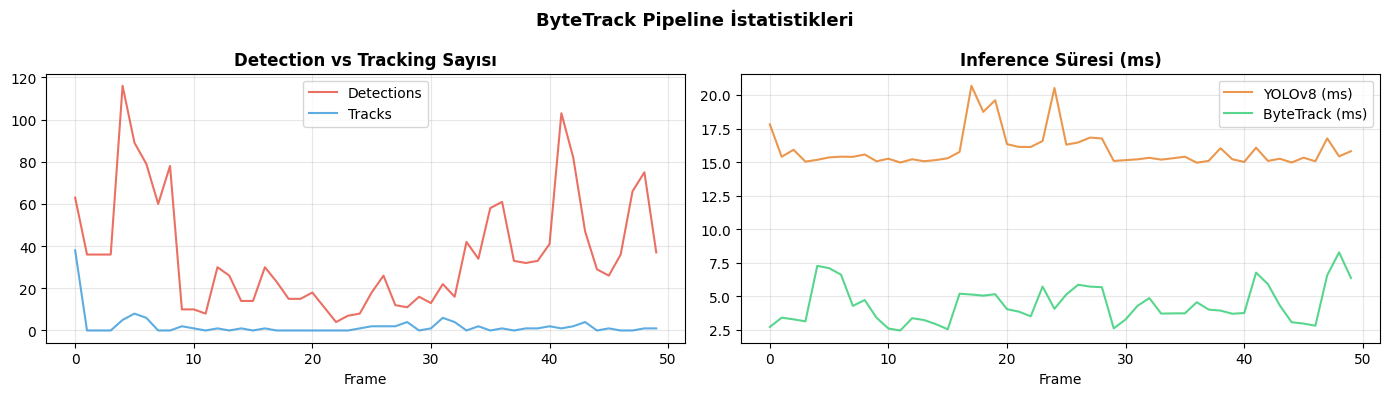

In [10]:
import pandas as pd

df = pd.DataFrame(tracking_stats)
print(df.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df['frame'], df['detections'], label='Detections', color='#e74c3c', alpha=0.8)
axes[0].plot(df['frame'], df['tracks'],     label='Tracks',     color='#3498db', alpha=0.8)
axes[0].set_title('Detection vs Tracking Sayısı', fontweight='bold')
axes[0].set_xlabel('Frame'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(df['frame'], df['t_detect'], label='YOLOv8 (ms)', color='#e67e22', alpha=0.8)
axes[1].plot(df['frame'], df['t_track'],  label='ByteTrack (ms)', color='#2ecc71', alpha=0.8)
axes[1].set_title('Inference Süresi (ms)', fontweight='bold')
axes[1].set_xlabel('Frame'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('ByteTrack Pipeline İstatistikleri', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/tracking_stats.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# İlk 5 annotated frame'i göster
if annotated_frames:
    n = len(annotated_frames)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1: axes = [axes]
    for i, (ax, fr) in enumerate(zip(axes, annotated_frames)):
        ax.imshow(fr); ax.set_title(f'Frame {i+1}', fontweight='bold'); ax.axis('off')
    plt.suptitle('ByteTrack — Annotated Frames', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/tracking_frames.png', dpi=150, bbox_inches='tight')
    plt.show()

print('\n✅ GÜN 7 TAMAMLANDI!')
print('   Sonraki: day8_bytetrack_hyperparams.ipynb')

Output hidden; open in https://colab.research.google.com to view.

---
## ✅ Gün 7 Özet
| Bileşen | Değer |
|---------|-------|
| Tracking | supervision ByteTrack |
| conf threshold | 0.25 |
| track_activation_threshold | 0.25 |
| lost_track_buffer | 30 frame |
| minimum_matching_threshold | 0.8 |

**Sonraki (Gün 8):** Hiperparametre optimizasyonu → `day8_bytetrack_hyperparams.ipynb`